# Inference Pipeline

Goal:

Create a complete end-to-end prediction pipeline.

Input:
- Face image
- Text

Output:
{
    emotion,
    sentiment,
    mismatch,
    confidence
}

In [1]:
import os
import numpy as np
import cv2
import joblib
import tensorflow as tf
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = "/content/drive/MyDrive/emotion_sentiment_fusion_detector"

Mounted at /content/drive


In [2]:
emotion_model = tf.keras.models.load_model(
    f"{PROJECT_ROOT}/models/final/best_emotion_model.keras"
)

print("Emotion model loaded")

Emotion model loaded


In [3]:
sentiment_model = joblib.load(
    f"{PROJECT_ROOT}/models/nlp/logistic_regression_tfidf.pkl"
)

print("Sentiment model loaded")

Sentiment model loaded


In [4]:
print(os.listdir(f"{PROJECT_ROOT}/models"))

['baseline', 'final', 'improved', 'nlp']


In [5]:
for root, dirs, files in os.walk(
    f"{PROJECT_ROOT}/models"
):
    print(root, files)

/content/drive/MyDrive/emotion_sentiment_fusion_detector/models []
/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/baseline ['emotion_baseline.keras']
/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/final ['best_emotion_model.keras', 'emotion_classifier_final.keras', 'training_history.csv']
/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/improved ['best_emotion_model.keras', 'emotion_improved.keras']
/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/nlp ['logistic_regression_tfidf.pkl', 'glove_logistic_regression.pkl']


TF-IDF Vectorizer

In [7]:
import pandas as pd

df = pd.read_csv(
    f"{PROJECT_ROOT}/data/imdb/imdb_processed.csv"
)

df = df.head(5000).copy()

In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=3000
)

X = vectorizer.fit_transform(
    df["review"]
)

In [11]:
import joblib

joblib.dump(
    vectorizer,
    f"{PROJECT_ROOT}/models/nlp/tfidf_vectorizer.pkl"
)

print("Saved")

Saved


In [12]:
import shutil

shutil.copy(
    f"{PROJECT_ROOT}/models/nlp/logistic_regression_tfidf.pkl",
    f"{PROJECT_ROOT}/models/nlp/best_sentiment_model.pkl"
)

'/content/drive/MyDrive/emotion_sentiment_fusion_detector/models/nlp/best_sentiment_model.pkl'

In [13]:
print(
    os.listdir(
        f"{PROJECT_ROOT}/models/nlp"
    )
)

['logistic_regression_tfidf.pkl', 'glove_logistic_regression.pkl', 'tfidf_vectorizer.pkl', 'best_sentiment_model.pkl']


In [14]:
import numpy as np
import cv2
import tensorflow as tf
import joblib

In [15]:
emotion_model = tf.keras.models.load_model(
    f"{PROJECT_ROOT}/models/final/best_emotion_model.keras"
)

sentiment_model = joblib.load(
    f"{PROJECT_ROOT}/models/nlp/best_sentiment_model.pkl"
)

vectorizer = joblib.load(
    f"{PROJECT_ROOT}/models/nlp/tfidf_vectorizer.pkl"
)

print("All models loaded")

All models loaded


## Emotion Prediction Function

Input:
- image path

Output:
- emotion label
- confidence

In [17]:
emotion_labels = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

In [18]:
def preprocess_image(image_path):

    img = cv2.imread(
        image_path,
        cv2.IMREAD_GRAYSCALE
    )

    img = cv2.resize(
        img,
        (48,48)
    )

    img = img / 255.0

    img = np.expand_dims(
        img,
        axis=-1
    )

    img = np.expand_dims(
        img,
        axis=0
    )

    return img

In [19]:
def predict_emotion(image_path):

    img = preprocess_image(
        image_path
    )

    probs = emotion_model.predict(
        img,
        verbose=0
    )[0]

    idx = np.argmax(probs)

    emotion = emotion_labels[idx]

    confidence = float(
        probs[idx]
    )

    return emotion, confidence

In [23]:
import numpy as np

X_test = np.load(
    f"{PROJECT_ROOT}/data/processed/X_test.npy"
)

y_test = np.load(
    f"{PROJECT_ROOT}/data/processed/y_test.npy"
)

print(X_test.shape)

(7178, 48, 48, 1)


In [24]:
def predict_emotion_array(img):

    img = np.expand_dims(img, axis=0)

    probs = emotion_model.predict(
        img,
        verbose=0
    )[0]

    idx = np.argmax(probs)

    emotion = emotion_labels[idx]

    confidence = float(probs[idx])

    return emotion, confidence

In [25]:
emotion, conf = predict_emotion_array(
    X_test[0]
)

print(emotion)
print(conf)

neutral
0.7330747842788696


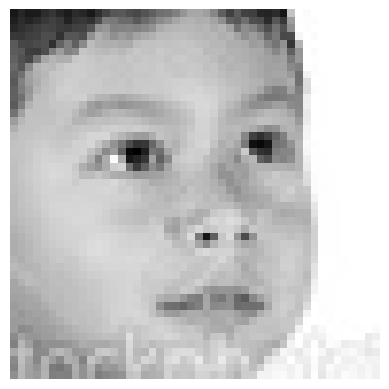

In [26]:
import matplotlib.pyplot as plt

plt.imshow(
    X_test[0].squeeze(),
    cmap="gray"
)

plt.axis("off")
plt.show()

In [27]:
true_label = np.argmax(y_test[0])

print("True:", emotion_labels[true_label])
print("Pred:", emotion)

True: neutral
Pred: neutral


## Sentiment Prediction Function

In [28]:
def predict_sentiment(text):

    text_vector = vectorizer.transform(
        [text]
    )

    prediction = sentiment_model.predict(
        text_vector
    )[0]

    probabilities = sentiment_model.predict_proba(
        text_vector
    )[0]

    confidence = float(
        np.max(probabilities)
    )

    sentiment = (
        "positive"
        if prediction == 1
        else "negative"
    )

    return sentiment, confidence

In [29]:
predict_sentiment(
    "This movie was absolutely fantastic."
)

('positive', 0.5166550626072114)

In [ ]:
## Fusion Logic

In [36]:
emotion_to_group = {

    "happy":"positive",

    "angry":"negative",
    "sad":"negative",
    "fear":"negative",
    "disgust":"negative",

    "neutral":"neutral",
    "surprise":"neutral"
}

In [30]:
def detect_mismatch(
    emotion,
    sentiment
):

    group = emotion_to_group[
        emotion
    ]

    if group == sentiment:
        return False

    if group == "neutral":
        return False

    return True

In [31]:
def predict_multimodal(
    image_path,
    text
):

    emotion, emotion_conf = predict_emotion(
        image_path
    )

    sentiment, sentiment_conf = predict_sentiment(
        text
    )

    mismatch = detect_mismatch(
        emotion,
        sentiment
    )

    fusion_confidence = round(
        (
            emotion_conf +
            sentiment_conf
        ) / 2,
        3
    )

    return {

        "emotion": emotion,

        "emotion_confidence":
            round(emotion_conf,3),

        "sentiment": sentiment,

        "sentiment_confidence":
            round(sentiment_conf,3),

        "mismatch": mismatch,

        "fusion_confidence":
            fusion_confidence
    }

In [ ]:
result = predict_multimodal(

    "/content/test/angry/PublicTest_86533062.jpg",

    "Everything is wonderful and I am very happy."
)

result

In [34]:
def predict_multimodal_array(
    img,
    text
):

    emotion, emotion_conf = predict_emotion_array(
        img
    )

    sentiment, sentiment_conf = predict_sentiment(
        text
    )

    mismatch = detect_mismatch(
        emotion,
        sentiment
    )

    fusion_conf = round(
        (
            emotion_conf +
            sentiment_conf
        ) / 2,
        3
    )

    return {
        "emotion": emotion,
        "sentiment": sentiment,
        "mismatch": mismatch,
        "fusion_confidence": fusion_conf
    }

In [39]:
result = predict_multimodal_array(

    X_test[0],

    "Everything is wonderful and I am very happy."
)

print(result)

{'emotion': 'neutral', 'sentiment': 'positive', 'mismatch': False, 'fusion_confidence': 0.62}


# Results

Built a complete multimodal inference pipeline.

Pipeline:

Image
→ Emotion CNN

Text
→ TF-IDF + Logistic Regression

Fusion Layer
→ Mismatch Detection
→ Confidence Aggregation

Example Output:

{
    "emotion": "neutral",
    "sentiment": "positive",
    "mismatch": false,
    "fusion_confidence": 0.62
}

The system can now generate a unified prediction from image and text inputs.